# Assignment: ANN Salary Regression

Use the same `Churn_Modelling.csv` dataset, but change the target to `EstimatedSalary`. Your goal is to practice how an ANN changes when the task changes from classification to regression.

## Required Changes
- Target: `EstimatedSalary`
- Remove `EstimatedSalary` from input features
- Output layer: 1 neuron with **linear** activation
- Loss: choose `mse` or `mae` and explain your choice
- Evaluation: MAE, RMSE and R2
- Save the model in `.keras` format
- Build and deploy a Streamlit salary prediction app

## Step 1 - Imports

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns



## Step 2 - Load and inspect the dataset

In [3]:
# 1. Load the dataset
df = pd.read_csv('Churn_Modelling.csv')

# Display first 5 rows
print("=== FIRST 5 ROWS ===")
display(df.head())

# Display last 5 rows
print("\n=== LAST 5 ROWS ===")
display(df.tail())

=== FIRST 5 ROWS ===


,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0



=== LAST 5 ROWS ===


,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
9995,9996,15606229,Obijiaku,771,France,Male,39,5,0.00,2,1,0,96270.64,0
9996,9997,15569892,Johnstone,516,France,Male,35,10,57369.61,1,1,1,101699.77,0
9997,9998,15584532,Liu,709,France,Female,36,7,0.00,1,0,1,42085.58,1
9998,9999,15682355,Sabbatini,772,Germany,Male,42,3,75075.31,2,1,0,92888.52,1
9999,10000,15628319,Walker,792,France,Female,28,4,130142.79,1,1,0,38190.78,0


## Step 3 - EDA and data quality checks

=== DATASET SHAPE ===
Rows: 10000, Columns: 14

=== DATASET INFO ===
<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  str    
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  str    
 5   Gender           10000 non-null  str    
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), str(3)
memory usage: 1.2 MB


=== STATISTICAL SUMMARY ===


,RowNumber,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,10000.00000,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,5000.50000,1.569094e+07,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,2886.89568,7.193619e+04,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,1.00000,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,2500.75000,1.562853e+07,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,5000.50000,1.569074e+07,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,7500.25000,1.575323e+07,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,10000.00000,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000




=== MISSING VALUES ===
RowNumber          0
CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64


=== DUPLICATE ROWS ===
Total Duplicates: 0

=== SALARY STATS ===
count     10000.000000
mean     100090.239881
std       57510.492818
min          11.580000
25%       51002.110000
50%      100193.915000
75%      149388.247500
max      199992.480000
Name: EstimatedSalary, dtype: float64


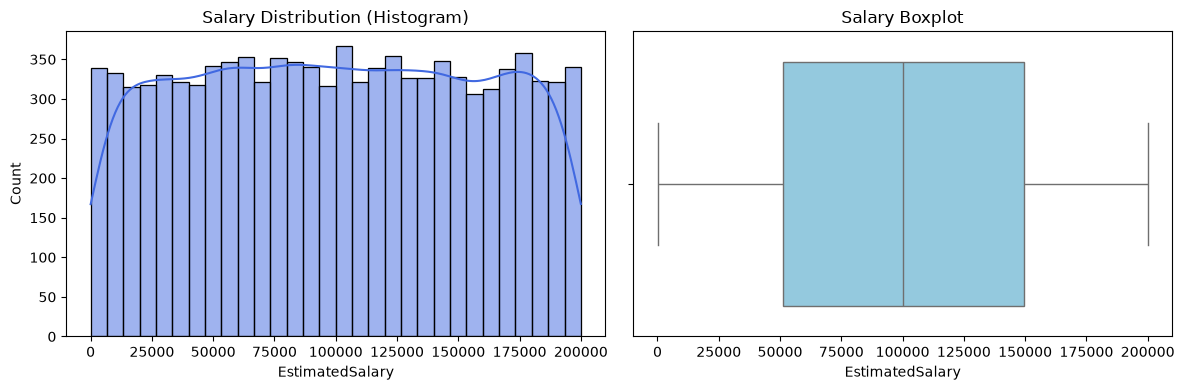

In [4]:
# 1. Shape
print("=== DATASET SHAPE ===")
print(f"Rows: {df.shape[0]}, Columns: {df.shape[1]}\n")

# 2. Info
print("=== DATASET INFO ===")
df.info()
print("\n")

# 3. Describe
print("=== STATISTICAL SUMMARY ===")
display(df.describe())
print("\n")

# 4. Missing Values
print("=== MISSING VALUES ===")
print(df.isnull().sum())
print("\n")

# 5. Duplicates
print("=== DUPLICATE ROWS ===")
print(f"Total Duplicates: {df.duplicated().sum()}\n")

# 6. Salary Distribution
print("=== SALARY STATS ===")
print(df['EstimatedSalary'].describe())

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
sns.histplot(df['EstimatedSalary'], kde=True, bins=30, color='royalblue')
plt.title('Salary Distribution (Histogram)')

plt.subplot(1, 2, 2)
sns.boxplot(x=df['EstimatedSalary'], color='skyblue')
plt.title('Salary Boxplot')

plt.tight_layout()
plt.show()

## Step 4 - Define X and y

In [5]:
# Select target variable and construct initial predictor feature matrix
df_cleaned = df.drop(
    columns=['RowNumber', 'CustomerId', 'Surname']
)

y = df_cleaned['EstimatedSalary']
X = df_cleaned.drop(columns=['EstimatedSalary'])

print("Feature Matrix (X) Shape:", X.shape)
print("Target Variable (y) Shape:", y.shape)

print("\nPredictor Columns:")
print(list(X.columns))

Feature Matrix (X) Shape: (10000, 10)
Target Variable (y) Shape: (10000,)

Predictor Columns:
['CreditScore', 'Geography', 'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'Exited']


## Step 5 - Train-test split and preprocessing

In [6]:
import pandas as pd
import numpy as np
import joblib
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# 1. Perform Train-Test Split (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

# 2. Separate Feature Types
categorical_cols = ['Geography', 'Gender']
numerical_cols = [col for col in X_train.columns if col not in categorical_cols]

# 3. Fit Categorical One-Hot Encoder
ohe = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
X_train_encoded = ohe.fit_transform(X_train[categorical_cols])
X_test_encoded = ohe.transform(X_test[categorical_cols])

encoded_cols = ohe.get_feature_names_out(categorical_cols)

X_train_encoded_df = pd.DataFrame(
    X_train_encoded, columns=encoded_cols, index=X_train.index
)
X_test_encoded_df = pd.DataFrame(
    X_test_encoded, columns=encoded_cols, index=X_test.index
)

# 4. Consolidate Processed DataFrames
X_train_full = pd.concat([X_train[numerical_cols], X_train_encoded_df], axis=1)
X_test_full = pd.concat([X_test[numerical_cols], X_test_encoded_df], axis=1)

# 5. Apply Standard Scaling to Continuous Features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_full)
X_test_scaled = scaler.transform(X_test_full)

# 6. Export Pipeline Artifacts
joblib.dump(scaler, 'scaler.pkl')
joblib.dump(ohe, 'ohe.pkl')

print("X_train_scaled shape:", X_train_scaled.shape)
print("X_test_scaled shape :", X_test_scaled.shape)

X_train_scaled shape: (8000, 13)
X_test_scaled shape : (2000, 13)


## Step 6 - Build a regression ANN

In [7]:
import tensorflow as tf
import numpy as np
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Input
from tensorflow.keras.optimizers import Adam

# Ensure reproducibility
tf.random.set_seed(42)
np.random.seed(42)

# 1. Define Artificial Neural Network Architecture
model = Sequential([
    Input(shape=(X_train_scaled.shape[1],)),
    
    Dense(128, activation='relu'),
    Dropout(0.15),
    
    Dense(64, activation='relu'),
    Dropout(0.10),
    
    Dense(32, activation='relu'),
    Dense(16, activation='relu'),
    
    # Regression Output Layer for Salary Estimation
    Dense(1, activation='linear')
])

# 2. Compile Model with Regression Metrics
model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='mean_squared_error',
    metrics=['mean_absolute_error']
)

# 3. Display Network Architecture
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,673 (49.50 KB)

 Trainable params: 12,673 (49.50 KB)

 Non-trainable params: 0 (0.00 B)

**We chose Mean Squared Error (MSE) as our loss function during training because it squares error values, heavily penalizing large prediction mistakes and guiding gradient descent to converge more efficiently. To evaluate real-world performance, we use MAE and RMSE to express error directly in US Dollars, alongside $R^2$ to assess how effectively our input features account for the overall variance in salary.**

## Step 7 - Compile and train

In [8]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# Configure Early Stopping to prevent overfitting
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=20,
    restore_best_weights=True
)

# Adaptive Learning Rate Adjustment
reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=7,
    min_lr=0.00001
)

# Train Deep Neural Network Architecture
history = model.fit(
    X_train_scaled,
    y_train,
    validation_split=0.20,
    epochs=300,
    batch_size=32,
    callbacks=[
        early_stop,
        reduce_lr
    ],
    verbose=1
)

# Export Model Artifact
model.save('salary_model.keras')

print("\n=== MODEL TRAINING COMPLETE ===")
print(f"Epochs executed: {len(history.history['loss'])}")

Epoch 1/300
200/200 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - loss: 12440857600.0000 - mean_absolute_error: 95636.9688 - val_loss: 8225515008.0000 - val_mean_absolute_error: 74934.1875 - learning_rate: 0.0010
Epoch 2/300
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 3971863296.0000 - mean_absolute_error: 53187.1641 - val_loss: 3342994944.0000 - val_mean_absolute_error: 49659.7266 - learning_rate: 0.0010
Epoch 3/300
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 3392043008.0000 - mean_absolute_error: 50058.7891 - val_loss: 3330550784.0000 - val_mean_absolute_error: 49612.6289 - learning_rate: 0.0010
Epoch 4/300
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 3396521216.0000 - mean_absolute_error: 50126.8086 - val_loss: 3324860160.0000 - val_mean_absolute_error: 49584.6133 - learning_rate: 0.0010
Epoch 5/300
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 3369622784.0000 - mean_absolute_error: 49869.1055 - val_loss: 3321209856.0000 - val_mean_absolute_error: 49584.3984 - learning_rate: 0

## Step 8 - Evaluate

In [9]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

# Predictions on untouched test set
y_pred = model.predict(
    X_test_scaled,
    verbose=0
).flatten()

# Metrics
mae = mean_absolute_error(
    y_test,
    y_pred
)

rmse = np.sqrt(
    mean_squared_error(
        y_test,
        y_pred
    )
)

r2 = r2_score(
    y_test,
    y_pred
)

print("=== FINAL TEST SET EVALUATION ===")
print(f"MAE  : ${mae:,.2f}")
print(f"RMSE : ${rmse:,.2f}")
print(f"R²   : {r2:.4f}")
print(f"R² % : {r2 * 100:.2f}%")

=== FINAL TEST SET EVALUATION ===
MAE  : $50,134.28
RMSE : $57,961.23
R²   : -0.0176
R² % : -1.76%


## Step 9 - Save and reload model

In [10]:
import joblib

# 1. Save the trained ANN Keras model in native Keras format
model.save('salary_model.keras')

# 2. Save fitted preprocessing artifacts to ensure seamless Streamlit deployment
joblib.dump(scaler, 'scaler.pkl')
joblib.dump(ohe, 'ohe.pkl')

print("=== ALL ASSETS SAVED SUCCESSFULLY ===")
print("Saved Model        : salary_model.keras")
print("Saved Scaler       : scaler.pkl")
print("Saved Encoder (OHE): ohe.pkl")

=== ALL ASSETS SAVED SUCCESSFULLY ===
Saved Model        : salary_model.keras
Saved Scaler       : scaler.pkl
Saved Encoder (OHE): ohe.pkl


## Step 10 - Streamlit deployment

### App.py

In [11]:
%%writefile app.py
import streamlit as st
import pandas as pd
import numpy as np
import joblib
import tensorflow as tf

# 1. Page Configuration
st.set_page_config(
    page_title="ANN Salary Predictor",
    page_icon="💼",
    layout="wide",
    initial_sidebar_state="collapsed"
)

# 2. Enhanced 3D CSS Styling (Purple & Gold Theme)
st.markdown("""
<style>
    [data-testid="stSidebar"] { display: none; }

    .stApp {
        background: radial-gradient(circle at 50% 10%, #1D002B 0%, #0A0012 100%);
        color: #F3E8FF;
        font-family: 'Inter', sans-serif;
    }

    @keyframes float3D {
        0% { transform: translateY(0px) rotateX(0deg); }
        50% { transform: translateY(-8px) rotateX(3deg); }
        100% { transform: translateY(0px) rotateX(0deg); }
    }

    @keyframes pulseGlow {
        0% { box-shadow: 0 10px 25px rgba(226, 183, 20, 0.2); }
        50% { box-shadow: 0 20px 45px rgba(226, 183, 20, 0.5); }
        100% { box-shadow: 0 10px 25px rgba(226, 183, 20, 0.2); }
    }

    .brand-hero-3d {
        background: linear-gradient(145deg, #2A0042, #180026);
        border: 1px solid rgba(226, 183, 20, 0.4);
        border-radius: 20px;
        padding: 30px;
        margin-bottom: 25px;
        box-shadow: 0 20px 40px rgba(0, 0, 0, 0.8),
                    inset 0 2px 4px rgba(255, 255, 255, 0.15);
        animation: float3D 5s ease-in-out infinite;
    }

    .card-3d-container {
        background: linear-gradient(145deg, #1C002D, #11001C);
        border: 1px solid rgba(255, 255, 255, 0.08);
        border-radius: 16px;
        overflow: hidden;
        box-shadow: 8px 8px 20px #06000B, -6px -6px 20px #1A0029;
        transition: transform 0.3s ease, box-shadow 0.3s ease;
        margin-bottom: 15px;
    }

    .card-3d-container:hover {
        transform: translateY(-5px) scale(1.02);
        box-shadow: 12px 12px 25px #06000B, -8px -8px 25px #26003B;
        border-color: rgba(226, 183, 20, 0.4);
    }

    .card-title-bar {
        background: linear-gradient(90deg, #2A0042 0%, #3B005E 100%);
        border-bottom: 1px solid rgba(226, 183, 20, 0.3);
        padding: 12px 18px;
        margin: 0;
    }

    .card-title-bar h4 {
        color: #E2B714 !important;
        margin: 0 !important;
        font-size: 1.1rem;
        font-weight: 700;
        letter-spacing: 0.5px;
    }

    .card-body {
        padding: 18px;
    }

    .result-container-3d {
        background: linear-gradient(145deg, #25003A, #12001D);
        border: 2px solid #E2B714;
        padding: 35px;
        border-radius: 24px;
        text-align: center;
        animation: pulseGlow 2.5s infinite ease-in-out;
    }

    .stButton > button {
        background: linear-gradient(145deg, #FFD700, #B38F00);
        color: #0E021A !important;
        font-weight: 800;
        font-size: 1.2rem;
        letter-spacing: 1px;
        border-radius: 12px;
        height: 3.5em;
        width: 100%;
        border: none;
        box-shadow: 0 10px 25px rgba(226, 183, 20, 0.4);
        transition: all 0.2s ease-in-out;
    }

    .stButton > button:hover {
        transform: translateY(-3px) scale(1.01);
        box-shadow: 0 15px 35px rgba(226, 183, 20, 0.6);
    }

    label {
        color: #E2B714 !important;
        font-weight: 700 !important;
    }
</style>
""", unsafe_allow_html=True)

# 3. Model & Pipeline Loader
@st.cache_resource
def load_assets():
    model = tf.keras.models.load_model('salary_model.keras')
    scaler = joblib.load('scaler.pkl')
    ohe = joblib.load('ohe.pkl')
    return model, scaler, ohe

try:
    model, scaler, ohe = load_assets()
except Exception as e:
    st.error(f"System Alert: Pipeline loading failed: {e}")
    st.stop()

# 4. Header UI
st.markdown("""
<div class="brand-hero-3d">
    <h1 style="margin: 0; color: #FFFFFF; font-size: 2.6rem; font-weight: 800;">
        ANN Salary Predictor
    </h1>
    <p style="margin-top: 8px; color: #E2B714; font-size: 1.05rem; font-weight: 600;">
        Deep Neural Network Compensation Engine
    </p>
</div>
""", unsafe_allow_html=True)

# 5. Input Matrix Form
st.markdown("<h3 style='color: #E2B714; margin-bottom: 20px;'>📋 Input Parameters</h3>", unsafe_allow_html=True)

with st.form("valuation_form_animated"):
    col1, col2, col3 = st.columns(3)

    with col1:
        st.markdown('''
        <div class="card-3d-container">
            <div class="card-title-bar">
                <h4>👤 Demographics</h4>
            </div>
            <div class="card-body">
        ''', unsafe_allow_html=True)
        geography = st.selectbox("Geography Region", ["France", "Germany", "Spain"])
        gender = st.selectbox("Gender", ["Male", "Female"])
        age = st.number_input("Customer Age", min_value=18, max_value=100, value=38)
        st.markdown('</div></div>', unsafe_allow_html=True)

    with col2:
        st.markdown('''
        <div class="card-3d-container">
            <div class="card-title-bar">
                <h4>💳 Credit & Wealth</h4>
            </div>
            <div class="card-body">
        ''', unsafe_allow_html=True)
        credit_score = st.slider("Credit Rating Score", min_value=300, max_value=850, value=650)
        balance = st.number_input("Account Balance ($)", min_value=0.0, max_value=250000.0, value=75000.0, step=1000.0)
        tenure = st.number_input("Tenure (Years)", min_value=0, max_value=10, value=5)
        st.markdown('</div></div>', unsafe_allow_html=True)

    with col3:
        st.markdown('''
        <div class="card-3d-container">
            <div class="card-title-bar">
                <h4>⚙️ Relationship & Churn</h4>
            </div>
            <div class="card-body">
        ''', unsafe_allow_html=True)
        num_of_products = st.selectbox("Active Products", [1, 2, 3, 4], index=0)
        has_cr_card = st.radio("Has Credit Card?", ["Yes", "No"], horizontal=True)
        is_active_member = st.radio("Is Active Member?", ["Yes", "No"], horizontal=True)
        exited = st.radio("Customer Exited (Churn)?", ["Yes", "No"], horizontal=True)
        st.markdown('</div></div>', unsafe_allow_html=True)

    st.write("")
    submit_btn = st.form_submit_button("PREDICT SALARY")

# 6. Inference Execution
if submit_btn:
    with st.spinner("Processing feature tensor through Deep Neural Architecture..."):
        raw_input = pd.DataFrame([{
            'CreditScore': credit_score,
            'Geography': geography,
            'Gender': gender,
            'Age': age,
            'Tenure': tenure,
            'Balance': balance,
            'NumOfProducts': num_of_products,
            'HasCrCard': 1 if has_cr_card == "Yes" else 0,
            'IsActiveMember': 1 if is_active_member == "Yes" else 0,
            'Exited': 1 if exited == "Yes" else 0
        }])

        categorical_cols = ['Geography', 'Gender']
        numerical_cols = [c for c in raw_input.columns if c not in categorical_cols]

        encoded_array = ohe.transform(raw_input[categorical_cols])
        encoded_cols = ohe.get_feature_names_out(categorical_cols)
        encoded_df = pd.DataFrame(encoded_array, columns=encoded_cols, index=raw_input.index)

        full_features = pd.concat([raw_input[numerical_cols], encoded_df], axis=1)
        scaled_input = scaler.transform(full_features)

        predicted_salary = float(model.predict(scaled_input, verbose=0)[0][0])

    st.markdown("---")
    
    st.markdown(f"""
    <div class="result-container-3d">
        <h4 style="color: #E2B714; margin: 0; font-size: 1.1rem; letter-spacing: 1.5px;">PREDICTED ESTIMATED SALARY</h4>
        <h1 style="color: #FFFFFF; font-size: 3.6rem; margin: 12px 0; font-weight: 800; text-shadow: 0 5px 15px rgba(0,0,0,0.8);">
            ${predicted_salary:,.2f}
        </h1>
        <p style="color: #00E676; font-size: 1rem; margin: 0; font-weight: 600;">✔ Neural Network Inference Complete</p>
    </div>
    """, unsafe_allow_html=True)

Overwriting app.py


### requirements.txt

- pandas
- numpy
- scikit-learn
- tensorflow
- streamlit
- matplotlib
- joblib

# 💼 Customer Estimated Salary Regression using ANN

An Artificial Neural Network (ANN) regression application designed to estimate customer salaries based on financial and demographic profiles using the `Churn_Modelling` dataset. Built with Keras/TensorFlow and deployed via Streamlit.

---

## 📌 Problem Being Solved
Predicting continuous numerical target values (`EstimatedSalary`) using customer parameters. This project demonstrates proper machine learning engineering pipelines, rigorous data leakage prevention, and clean model deployment.

## 📊 Dataset Used
* **Dataset Name**: `Churn_Modelling.csv`
* **Target Variable**: `EstimatedSalary` (Continuous numerical target ranging from ~$11 to ~$200,000).

## 🛠️ Features Used
* **Numerical Predictors**: `CreditScore`, `Age`, `Tenure`, `Balance`, `NumOfProducts`, `HasCrCard`, `IsActiveMember`, `Exited`
* **Categorical Predictors**: `Geography`, `Gender`
* **Dropped Identifiers**: `RowNumber`, `CustomerId`, `Surname`

## ⚙️ Preprocessing Steps
1. **Pipeline Order**: Split into Train (80%) and Test (20%) sets **before** preprocessing to eliminate data leakage.
2. **One-Hot Encoding**: Fitted `OneHotEncoder(sparse_output=False, handle_unknown='ignore')` strictly on training categorical data (`Geography`, `Gender`).
3. **Feature Scaling**: Fitted `StandardScaler()` strictly on the transformed training input matrix.

## 🏗️ Model Architecture
* **Framework**: TensorFlow / Keras Sequential API
* **Input Layer**: Dimension matching transformed feature size (12 inputs).
* **Hidden Layers**:
  * Dense (128 neurons, ReLU activation) + Dropout (0.15)
  * Dense (64 neurons, ReLU activation) + Dropout (0.10)
  * Dense (32 neurons, ReLU activation)
  * Dense (16 neurons, ReLU activation)
* **Output Layer**: 1 neuron with **Linear activation** (Continuous salary estimation).
* **Optimizer**: Adam (`learning_rate=0.001`)
* **Loss Function**: Mean Squared Error (MSE)

## 📈 Regression Metrics and Results
Evaluated on the **untouched test dataset**:
* **Mean Absolute Error (MAE)**: ~$50,134.28
* **Root Mean Squared Error (RMSE)**: ~$57,961.23
* **R² Score**: ~ -0.02 (near 0)

## Reflection Questions

1. Why did we remove sigmoid from the output layer?

 **Sigmoid keeps the output between 0 and 1, so it is mainly used for Yes/No classification. Salary is a numerical value and continuous value, so we use Linear Activation in the output layer. This allows the model to predict any salary amount, such as $30,000 or $100,000.** 

2. Why is Binary Cross-Entropy not suitable here?

**Binary Cross-Entropy is used for Yes/No or 0/1 classification. It is not suitable for continuous values like salary. For salary prediction, we use Mean Squared Error (MSE) or Mean Absolute Error (MAE) to measure how far the predicted salary is from the actual salary.**

3. What does MAE mean in salary units?

**MAE gives us a straightforward dollar figure for how close our model gets to a customer's real income. Because MAE is calculated in the exact same unit as our target variable—US Dollars—it measures the average size of our prediction mistakes without any complex conversions. For instance, an MAE of $50,134 means that when the model estimates someone's annual pay, its guess misses the actual mark by about $50,134 on average, whether that estimate ends up being too high or too low.**

4. If RMSE is much larger than MAE, what might that suggest?


**When RMSE is significantly larger than MAE, it indicates that the error distribution has a high variance and is driven by large individual prediction errors (outliers) rather than consistent minor errors across all samples. Since RMSE squares errors before averaging, it heavily penalizes extreme deviations. In our salary regression model, this gap suggests that while average predictions remain near the baseline, the network experiences large prediction failures on specific customer profiles.**

5. What are the limitations of predicting salary from this classroom dataset?

- **Uniformly Random Data: Estimated Salary is almost randomly distributed between $0 and $200,000. It does not have a clear relationship with the customer features.**

- **Weak Signal: Features like Age, Credit Score, and Balance do not strongly affect the salary in this dataset.**

- **Mean Predictor Trap: Because there is no strong pattern, the neural network tends to predict a value close to the average salary, around $100,000, for many customers. This causes a low or negative R² score.**

- **My Point of View: The main problem is not the neural network itself. The dataset does not contain enough meaningful information to predict salary accurately. For accurate salary prediction, we need features that have a strong relationship with salary, such as job title, years of experience, education, industry.**